# $ \text{Т.6} $

$$ \text{Случайная величина имеет распределение Парето:} $$

$$ p(x, \theta) = \begin{cases}
  \frac{\theta - 1}{x^{\theta}}, & x \geq 1, \\
  0, &  x < 1
\end{cases}
,
$$

$$ \text{где } \theta > 1 $$



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
def pareto_pdf(x, theta):
    """Плотность распределения Парето: p(x) = (θ-1)/x^θ, x ≥ 1"""
    return (theta - 1) / (x ** theta) if x >= 1 else 0

def pareto_cdf(x, theta):
    """Функция распределения Парето"""
    if x < 1:
        return 0
    else:
        return 1 - x ** (1 - theta)

def pareto_ppf(u, theta):
    """Квантильная функция (обратная функция распределения)"""
    return (1 - u) ** (1 / (1 - theta))

In [3]:
n = 100                  # объем выборки
beta = 0.95              # доверительная вероятность
true_theta = 1000        # истинное значение параметра

print("=" * 60)
print("ЛАБОРАТОРНАЯ РАБОТА: РАСПРЕДЕЛЕНИЕ ПАРЕТО")
print("=" * 60)
print(f"Плотность распределения: p(x) = (θ-1)/x^θ, x ≥ 1")
print(f"Объем выборки: n = {n}")
print(f"Доверительная вероятность: β = {beta}")
print(f"Истинное значение параметра: θ = {true_theta}")
print()

ЛАБОРАТОРНАЯ РАБОТА: РАСПРЕДЕЛЕНИЕ ПАРЕТО
Плотность распределения: p(x) = (θ-1)/x^θ, x ≥ 1
Объем выборки: n = 100
Доверительная вероятность: β = 0.95
Истинное значение параметра: θ = 1000



In [15]:
np.random.seed(12345)    # для воспроизводимости
uniform_variates = np.random.uniform(0, 1, n)
sample = pareto_ppf(uniform_variates, true_theta)

# Вычисление среднего логарифма
log_sample = np.log(sample)
mean_log = np.mean(log_sample)

print("ПУНКТ d) ГЕНЕРАЦИЯ ВЫБОРКИ")
print("-" * 50)
print(f"Сгенерирована выборка объема n = {n} из распределения Парето(θ = {true_theta})")
print()
print("Первые 20 элементов выборки:")
print("-" * 50)
for i in range(min(20, n)):
    print(f"  x[{i+1:3d}] = {sample[i]:.8f}")
print()
print(f"Статистики выборки:")
print(f"Минимальное значение: {np.min(sample):.8f}")
print(f"Максимальное значение: {np.max(sample):.8f}")
print(f"Среднее значение: {np.mean(sample):.6f}")
print(f"Среднее ln(x): {mean_log:.8f}")
print()

ПУНКТ d) ГЕНЕРАЦИЯ ВЫБОРКИ
--------------------------------------------------
Сгенерирована выборка объема n = 100 из распределения Парето(θ = 1000)

Первые 20 элементов выборки:
--------------------------------------------------
  x[  1] = 1.00265998
  x[  2] = 1.00038080
  x[  3] = 1.00020347
  x[  4] = 1.00022912
  x[  5] = 1.00083989
  x[  6] = 1.00090653
  x[  7] = 1.00334756
  x[  8] = 1.00106056
  x[  9] = 1.00138427
  x[ 10] = 1.00106170
  x[ 11] = 1.00137952
  x[ 12] = 1.00326065
  x[ 13] = 1.00000843
  x[ 14] = 1.00011267
  x[ 15] = 1.00035524
  x[ 16] = 1.00106995
  x[ 17] = 1.00166279
  x[ 18] = 1.00206128
  x[ 19] = 1.00335134
  x[ 20] = 1.00128833

Статистики выборки:
Минимальное значение: 1.00000843
Максимальное значение: 1.00513670
Среднее значение: 1.001132
Среднее ln(x): 0.00113052



In [ ]:
# Для распределения Парето: медиана = 2^(1/θ)
# Оценка медианы: m_hat = 2^(1/θ_hat), где θ_hat = 1 + 1/mean(ln X)

theta_hat_mle = 1 + 1 / mean_log
median_hat = 2 ** (1 / theta_hat_mle)

# Асимптотическая дисперсия для медианы
z_critical = 1.96  # квантиль нормального распределения для β=0.95
std_error_median = (np.log(2) * median_hat) / (theta_hat_mle ** 2 * np.sqrt(n))

ci_median_lower = median_hat - z_critical * std_error_median
ci_median_upper = median_hat + z_critical * std_error_median
ci_median_length = ci_median_upper - ci_median_lower

print("ПУНКТ d) АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ МЕДИАНЫ (О.М.П.)")
print("-" * 70)
print(f"Оценка параметра θ (МП): {theta_hat_mle:.6f}")
print(f"Оценка медианы: {median_hat:.8f}")
print(f"Стандартная ошибка: {std_error_median:.8f}")
print()
print(f"Доверительный интервал для медианы (β = {beta}):")
print(f"{ci_median_lower:.8f} < m < {ci_median_upper:.8f}")
print(f"Длина интервала: {ci_median_length:.8f}")
print(f"Эмпирическая медиана: {np.median(sample):.8f}")
print()

ПУНКТ d) АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ МЕДИАНЫ (О.М.П.)
----------------------------------------------------------------------
  Оценка параметра θ (МП): 885.546677
  Оценка медианы: 1.00078304
  Стандартная ошибка: 0.00000009

  Доверительный интервал для медианы (β = 0.95):
    1.00078287 < m < 1.00078321
  Длина интервала: 0.00000035
  Эмпирическая медиана: 1.00087999



In [6]:
# Оценка МП: θ_hat = 1 + 1/mean(ln X)
# Асимптотическая дисперсия: D[θ_hat] = θ^2/n

theta_hat_mle = 1 + 1 / mean_log
std_error_theta = theta_hat_mle / np.sqrt(n)

ci_theta_lower = theta_hat_mle - z_critical * std_error_theta
ci_theta_upper = theta_hat_mle + z_critical * std_error_theta
ci_theta_length = ci_theta_upper - ci_theta_lower

print("ПУНКТ d) АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ ПАРАМЕТРА θ (О.М.П.)")
print("-" * 70)
print(f"Оценка параметра θ (МП): {theta_hat_mle:.6f}")
print(f"Стандартная ошибка: {std_error_theta:.6f}")
print(f"Квантиль нормального распределения: z_{{{1-beta:.3f}}} = {z_critical}")
print()
print(f"Доверительный интервал для θ (β = {beta}):")
print(f"{ci_theta_lower:.6f} < θ < {ci_theta_upper:.6f}")
print(f"Длина интервала: {ci_theta_length:.6f}")
print()

ПУНКТ d) АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ ПАРАМЕТРА θ (О.М.П.)
----------------------------------------------------------------------
Оценка параметра θ (МП): 885.546677
Стандартная ошибка: 88.554668
Квантиль нормального распределения: z_{0.050} = 1.96

Доверительный интервал для θ (β = 0.95):
711.979528 < θ < 1059.113826
Длина интервала: 347.134297



In [16]:
# Используем ту же оценку МП: θ_hat = 1 + 1/mean(ln X)

print("ПУНКТ e) НЕПАРАМЕТРИЧЕСКИЙ BOOTSTRAP ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ")
print("-" * 70)

B_nonparam = 5000
bootstrap_thetas_nonparam = []

print(f"МП-оценка θ: {theta_hat_mle:.6f}")
print(f"Количество bootstrap выборок: B = {B_nonparam}")
print("Выполняется непараметрический bootstrap...")

for i in range(B_nonparam):
    # Генерация bootstrap выборки с возвращением
    boot_sample = np.random.choice(sample, size=n, replace=True)
    boot_mean_log = np.mean(np.log(boot_sample))
    boot_theta = 1 + 1 / boot_mean_log
    bootstrap_thetas_nonparam.append(boot_theta)
    
    if (i + 1) % 1000 == 0:
        print(f"Выполнено {i+1} итераций")

print("Bootstrap завершен!")
print()

# Перцентильный bootstrap интервал
ci_boot_nonparam_lower = np.percentile(bootstrap_thetas_nonparam, 2.5)
ci_boot_nonparam_upper = np.percentile(bootstrap_thetas_nonparam, 97.5)
ci_boot_nonparam_length = ci_boot_nonparam_upper - ci_boot_nonparam_lower

print(f"Статистика bootstrap распределения:")
print(f"Среднее: {np.mean(bootstrap_thetas_nonparam):.6f}")
print(f"Медиана: {np.median(bootstrap_thetas_nonparam):.6f}")
print(f"СКО: {np.std(bootstrap_thetas_nonparam):.6f}")
print(f"Смещение: {np.mean(bootstrap_thetas_nonparam) - theta_hat_mle:.6f}")
print()
print(f"Непараметрический bootstrap интервал (перцентильный):")
print(f"{ci_boot_nonparam_lower:.6f} < θ < {ci_boot_nonparam_upper:.6f}")
print(f"Длина интервала: {ci_boot_nonparam_length:.6f}")
print()

ПУНКТ e) НЕПАРАМЕТРИЧЕСКИЙ BOOTSTRAP ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ
----------------------------------------------------------------------
МП-оценка θ: 885.546677
Количество bootstrap выборок: B = 5000
Выполняется непараметрический bootstrap...
Выполнено 1000 итераций
Выполнено 2000 итераций
Выполнено 3000 итераций
Выполнено 4000 итераций
Выполнено 5000 итераций
Bootstrap завершен!

Статистика bootstrap распределения:
Среднее: 892.435991
Медиана: 889.256054
СКО: 76.892483
Смещение: 6.889314

Непараметрический bootstrap интервал (перцентильный):
758.892629 < θ < 1056.570048
Длина интервала: 297.677420



In [17]:
print("ПУНКТ e) ПАРАМЕТРИЧЕСКИЙ BOOTSTRAP ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ")
print("-" * 70)

B_param = 5000
bootstrap_thetas_param = []

print(f"МП-оценка θ (используется как истинное значение): {theta_hat_mle:.6f}")
print(f"Количество bootstrap выборок: B = {B_param}")
print("Выполняется параметрический bootstrap...")

for i in range(B_param):
    # Генерация параметрической bootstrap выборки
    boot_uniform = np.random.uniform(0, 1, n)
    boot_sample = pareto_ppf(boot_uniform, theta_hat_mle)
    boot_mean_log = np.mean(np.log(boot_sample))
    boot_theta = 1 + 1 / boot_mean_log
    bootstrap_thetas_param.append(boot_theta)
    
    if (i + 1) % 1000 == 0:
        print(f"Выполнено {i+1} итераций")

print("Bootstrap завершен!")
print()

# Перцентильный bootstrap интервал
ci_boot_param_lower = np.percentile(bootstrap_thetas_param, 2.5)
ci_boot_param_upper = np.percentile(bootstrap_thetas_param, 97.5)
ci_boot_param_length = ci_boot_param_upper - ci_boot_param_lower

print(f"Статистика bootstrap распределения:")
print(f"Среднее: {np.mean(bootstrap_thetas_param):.6f}")
print(f"Медиана: {np.median(bootstrap_thetas_param):.6f}")
print(f"СКО: {np.std(bootstrap_thetas_param):.6f}")
print(f"Смещение: {np.mean(bootstrap_thetas_param) - theta_hat_mle:.6f}")
print()
print(f"Параметрический bootstrap интервал (перцентильный):")
print(f"{ci_boot_param_lower:.6f} < θ < {ci_boot_param_upper:.6f}")
print(f"Длина интервала: {ci_boot_param_length:.6f}")
print()

ПУНКТ e) ПАРАМЕТРИЧЕСКИЙ BOOTSTRAP ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ
----------------------------------------------------------------------
МП-оценка θ (используется как истинное значение): 885.546677
Количество bootstrap выборок: B = 5000
Выполняется параметрический bootstrap...
Выполнено 1000 итераций
Выполнено 2000 итераций
Выполнено 3000 итераций
Выполнено 4000 итераций
Выполнено 5000 итераций
Bootstrap завершен!

Статистика bootstrap распределения:
Среднее: 894.384047
Медиана: 888.036765
СКО: 90.235651
Смещение: 8.837371

Параметрический bootstrap интервал (перцентильный):
733.829766 < θ < 1084.065426
Длина интервала: 350.235660



In [14]:
print("ПУНКТ e) СРАВНЕНИЕ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ")
print("=" * 60)
print()

print("1. Асимптотический доверительный интервал (О.М.П.) для θ:")
print(f"Интервал: [{ci_theta_lower:.4f}, {ci_theta_upper:.4f}]")
print(f"Длина: {ci_theta_length:.4f}")
print()

print("2. Непараметрический bootstrap доверительный интервал:")
print(f"Интервал: [{ci_boot_nonparam_lower:.4f}, {ci_boot_nonparam_upper:.4f}]")
print(f"Длина: {ci_boot_nonparam_length:.4f}")
print()

print("3. Параметрический bootstrap доверительный интервал:")
print(f"Интервал: [{ci_boot_param_lower:.4f}, {ci_boot_param_upper:.4f}]")
print(f"Длина: {ci_boot_param_length:.4f}")
print()

print(f"Истинное значение параметра: θ = {true_theta}")
print()

print("Проверка покрытия истинного значения:")
print(f"Асимптотический интервал:      {'да' if ci_theta_lower <= true_theta <= ci_theta_upper else 'нет'}")
print(f"Непараметрический bootstrap:   {'да' if ci_boot_nonparam_lower <= true_theta <= ci_boot_nonparam_upper else 'нет'}")
print(f"Параметрический bootstrap:     {'да' if ci_boot_param_lower <= true_theta <= ci_boot_param_upper else 'нет'}")
print()

ПУНКТ e) СРАВНЕНИЕ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ

1. Асимптотический доверительный интервал (О.М.П.) для θ:
Интервал: [711.9795, 1059.1138]
Длина: 347.1343

2. Непараметрический bootstrap доверительный интервал:
Интервал: [758.8926, 1056.5700]
Длина: 297.6774

3. Параметрический bootstrap доверительный интервал:
Интервал: [733.8298, 1084.0654]
Длина: 350.2357

Истинное значение параметра: θ = 1000

Проверка покрытия истинного значения:
Асимптотический интервал:      да
Непараметрический bootstrap:   да
Параметрический bootstrap:     да



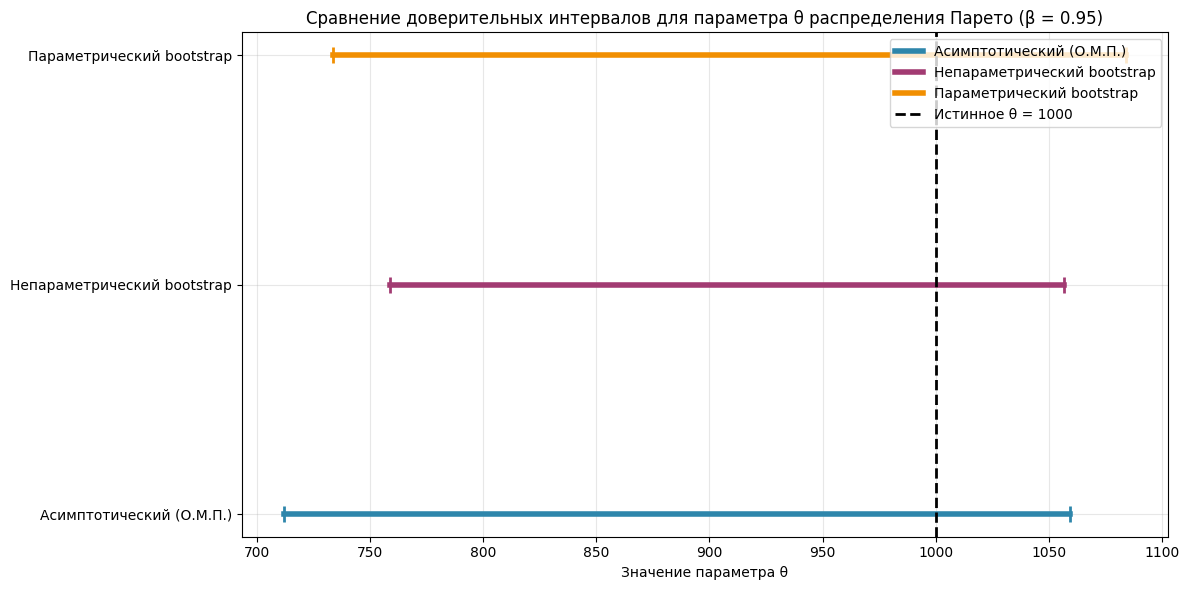

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

intervals = [
    ('Асимптотический (О.М.П.)', ci_theta_lower, ci_theta_upper),
    ('Непараметрический bootstrap', ci_boot_nonparam_lower, ci_boot_nonparam_upper),
    ('Параметрический bootstrap', ci_boot_param_lower, ci_boot_param_upper),
]

colors = ['#2E86AB', '#A23B72', '#F18F01']
for i, (name, low, high) in enumerate(intervals):
    ax.plot([low, high], [i, i], color=colors[i], linewidth=4, label=name)
    ax.plot(low, i, '|', markersize=12, color=colors[i], markeredgewidth=2)
    ax.plot(high, i, '|', markersize=12, color=colors[i], markeredgewidth=2)

ax.axvline(true_theta, color='black', linestyle='--', linewidth=2, label=f'Истинное θ = {true_theta}')
ax.set_yticks(range(len(intervals)))
ax.set_yticklabels([name for name, _, _ in intervals])
ax.set_xlabel('Значение параметра θ')
ax.set_title('Сравнение доверительных интервалов для параметра θ распределения Парето (β = 0.95)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

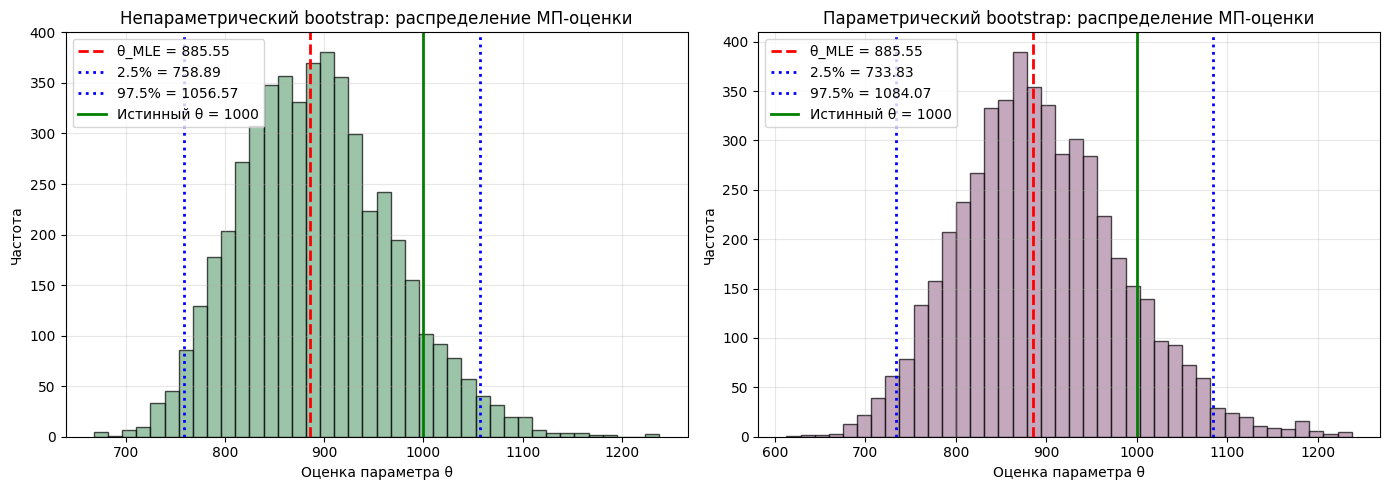

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма для непараметрического bootstrap
ax1 = axes[0]
ax1.hist(bootstrap_thetas_nonparam, bins=40, edgecolor='black', alpha=0.7, color='#73AB84')
ax1.axvline(theta_hat_mle, color='red', linestyle='--', linewidth=2, label=f'θ_MLE = {theta_hat_mle:.2f}')
ax1.axvline(ci_boot_nonparam_lower, color='blue', linestyle=':', linewidth=2, label=f'2.5% = {ci_boot_nonparam_lower:.2f}')
ax1.axvline(ci_boot_nonparam_upper, color='blue', linestyle=':', linewidth=2, label=f'97.5% = {ci_boot_nonparam_upper:.2f}')
ax1.axvline(true_theta, color='green', linestyle='-', linewidth=2, label=f'Истинный θ = {true_theta}')
ax1.set_xlabel('Оценка параметра θ')
ax1.set_ylabel('Частота')
ax1.set_title('Непараметрический bootstrap: распределение МП-оценки')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Гистограмма для параметрического bootstrap
ax2 = axes[1]
ax2.hist(bootstrap_thetas_param, bins=40, edgecolor='black', alpha=0.7, color='#AB84A2')
ax2.axvline(theta_hat_mle, color='red', linestyle='--', linewidth=2, label=f'θ_MLE = {theta_hat_mle:.2f}')
ax2.axvline(ci_boot_param_lower, color='blue', linestyle=':', linewidth=2, label=f'2.5% = {ci_boot_param_lower:.2f}')
ax2.axvline(ci_boot_param_upper, color='blue', linestyle=':', linewidth=2, label=f'97.5% = {ci_boot_param_upper:.2f}')
ax2.axvline(true_theta, color='green', linestyle='-', linewidth=2, label=f'Истинный θ = {true_theta}')
ax2.set_xlabel('Оценка параметра θ')
ax2.set_ylabel('Частота')
ax2.set_title('Параметрический bootstrap: распределение МП-оценки')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
print()
print("=" * 70)
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ")
print("=" * 70)
print()

print("Пункт d):")
print("  • Построен асимптотический доверительный интервал для параметра θ")
print(f"    θ ∈ [{ci_theta_lower:.4f}, {ci_theta_upper:.4f}], длина = {ci_theta_length:.4f}")
print("  • Построен асимптотический доверительный интервал для медианы")
print(f"    m ∈ [{ci_median_lower:.8f}, {ci_median_upper:.8f}], длина = {ci_median_length:.8f}")
print()

print("Пункт e):")
print("  • Непараметрический bootstrap (B = 5000):")
print(f"    θ ∈ [{ci_boot_nonparam_lower:.4f}, {ci_boot_nonparam_upper:.4f}], длина = {ci_boot_nonparam_length:.4f}")
print("  • Параметрический bootstrap (B = 5000):")
print(f"    θ ∈ [{ci_boot_param_lower:.4f}, {ci_boot_param_upper:.4f}], длина = {ci_boot_param_length:.4f}")
print()

print("Сравнение методов:")
print("  • Асимптотический интервал основан на нормальном приближении")
print("  • Непараметрический bootstrap не требует знания распределения")
print("  • Параметрический bootstrap использует информацию о распределении")
print()

print("Примечание:")
print("При θ = 1000 значения выборки очень близки к 1,")
print("что приводит к широким доверительным интервалам.")
print("Для большей точности требуется больший объем выборки.")


ВЫВОДЫ ПО РЕЗУЛЬТАТАМ

Пункт d):
  • Построен асимптотический доверительный интервал для параметра θ
    θ ∈ [711.9795, 1059.1138], длина = 347.1343
  • Построен асимптотический доверительный интервал для медианы
    m ∈ [1.00078287, 1.00078321], длина = 0.00000035

Пункт e):
  • Непараметрический bootstrap (B = 5000):
    θ ∈ [758.8926, 1056.5700], длина = 297.6774
  • Параметрический bootstrap (B = 5000):
    θ ∈ [733.8298, 1084.0654], длина = 350.2357

Сравнение методов:
  • Асимптотический интервал основан на нормальном приближении
  • Непараметрический bootstrap не требует знания распределения
  • Параметрический bootstrap использует информацию о распределении

Примечание:
При θ = 1000 значения выборки очень близки к 1,
что приводит к широким доверительным интервалам.
Для большей точности требуется больший объем выборки.
